In [1]:
import sys
import os
from pathlib import Path
# Go up until you find the project root
while not (Path.cwd() / ".gitignore").exists() and Path.cwd() != Path("/"):
    os.chdir("..")


In [2]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import fiona
from shapely.geometry import Point
import matplotlib.pyplot as plt
import numpy as np
from src.utils import split_pa_train_test_spatially, split_pa_train_test_kmeans
from src.pa_split import partition_sweep

<Axes: >

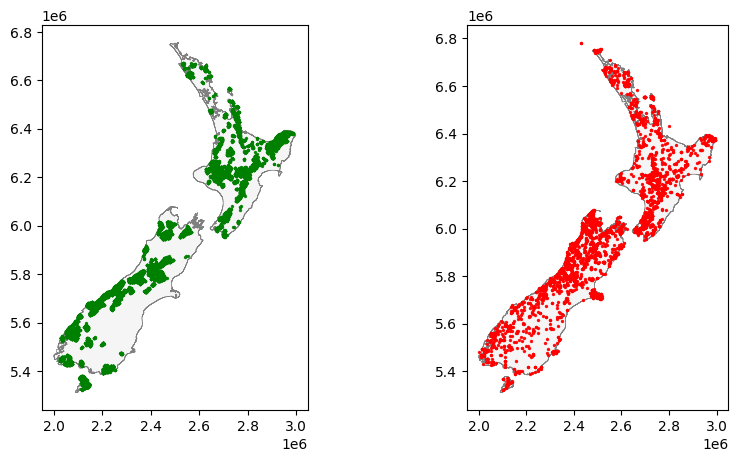

In [ ]:
region = 'awt'  # example region code
group = ''
group_ = '_' if group != '' else ''
gdf_map = gpd.read_file(f'data/raw/NCEAS/Borders/{region}.gpkg')  # path for a .gpkg

# read data\raw\NCEAS\Records\train_po\AWTtrain_po.csv with region variable
df_po = gpd.read_file(f'data/processed/NCEAS/Records/train_po/{region.upper()}train_po{group_}{group}.csv')


# data\raw\NCEAS\Records\test_pa\AWTtest_pa_bird.csv
df_pa = gpd.read_file(f'data/raw/NCEAS/Records/test_pa/{region.upper()}test_pa{group_}{group}.csv')
df_env = pd.read_csv(f'data/raw/NCEAS/Records/test_env/{region.upper()}test_env{group_}{group}.csv')
df_pa[['x','y']] = df_pa[['x','y']].astype('float')
# df_pa_tr, df_pa_te, foo1, foo2 = split_pa_train_test_spatially(df_pa, df_pa)

gdf_points_po = gpd.GeoDataFrame(
    df_po,
    geometry=gpd.points_from_xy(df_po.x, df_po.y),
    crs=str(gdf_map.crs)  # Set CRS (important!)
    )

gdf_points_pa = gpd.GeoDataFrame(
    df_pa,
    geometry=gpd.points_from_xy(df_pa.x, df_pa.y),
    crs=str(gdf_map.crs)  # Set CRS (important!)
    )


# fig, ax1, ax2 = plt.subplots(figsize=(5, 5), nrows=1, ncols=2)
fig, (ax1, ax2) = plt.subplots(figsize=(10, 5), nrows=1, ncols=2)
gdf_map.plot(ax=ax1, color="whitesmoke", edgecolor="gray", linewidth=0.5)
gdf_points_pa.plot(ax=ax1, color="green", markersize=2, label="Presence-Absence", alpha=0.9)
gdf_map.plot(ax=ax2, color="whitesmoke", edgecolor="gray", linewidth=0.5)
gdf_points_po.plot(ax=ax2, color="red", markersize=2, label="Presence-Only", alpha=0.9)
